## Plotting and Visualization
Making informative visualizations (sometimes called plots) is one of the most important tasks in data analysis. It may be a part of the exploratory process—for example, to help identify outliers or needed data transformations, or as a way of generating ideas for models. For others, building an interactive visualization for the web may be the end goal. Python has many add-on libraries for making static or dynamic visualizations, but I’ll be mainly focused on matplotlib and libraries that build on top
of it.

matplotlib is a desktop plotting package designed for creating plots and figures suitable for publication. The project was started by John Hunter in 2002 to enable a MATLAB-like plotting interface in Python. The matplotlib and IPython communities have collaborated to simplify interactive plotting from the IPython shell (and now, Jupyter notebook). matplotlib supports various GUI backends on all operating systems and can export visualizations to all of the common vector and raster graphics
formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.). With the exception of a few diagrams, nearly all of the graphics in this book were produced using matplotlib.

Over time, matplotlib has spawned a number of add-on toolkits for data visualization that use matplotlib for their underlying plotting. One of these is seaborn, which we explore later.

The simplest way to follow the code examples in the chapter is to output plots in the Jupyter notebook. To set this up, execute the following statement in a Jupyter
notebook:

In Jupyter Notebook and other IPython environments, %matplotlib inline is a magic command that enables the inline plotting feature.

What it does:
Inline plotting: It tells Matplotlib to render plots directly within the notebook interface, below the code cell that generated them. This means you don't need separate windows popping up for each plot, making your notebook more self-contained and easier to read.

How to use it:
Place it at the top of your notebook: Typically, you'll put %matplotlib inline at the beginning of your notebook, right after importing Matplotlib:

In [2]:
import numpy as np
import pandas as pd
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80
pd.options.display.max_columns = 20
np.random.seed(12345)
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
plt.rc("figure", figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

In [4]:
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

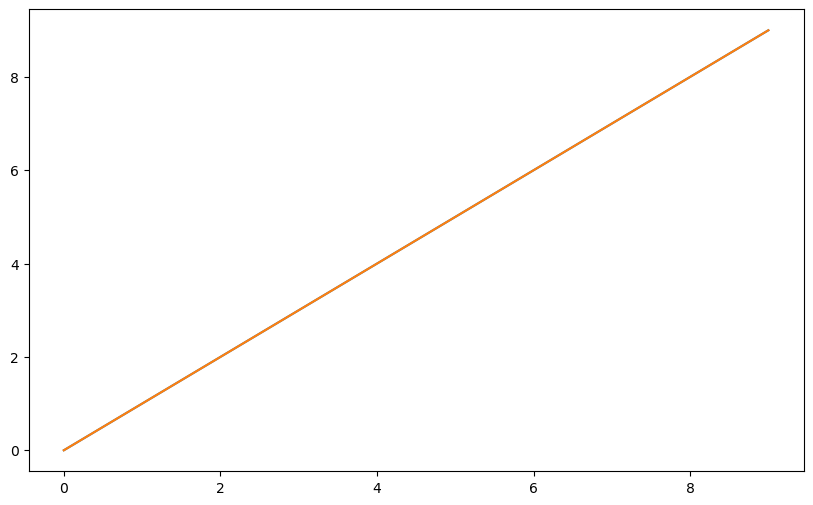

In [8]:
# # a line plot
plt.plot(data)
plt.show()

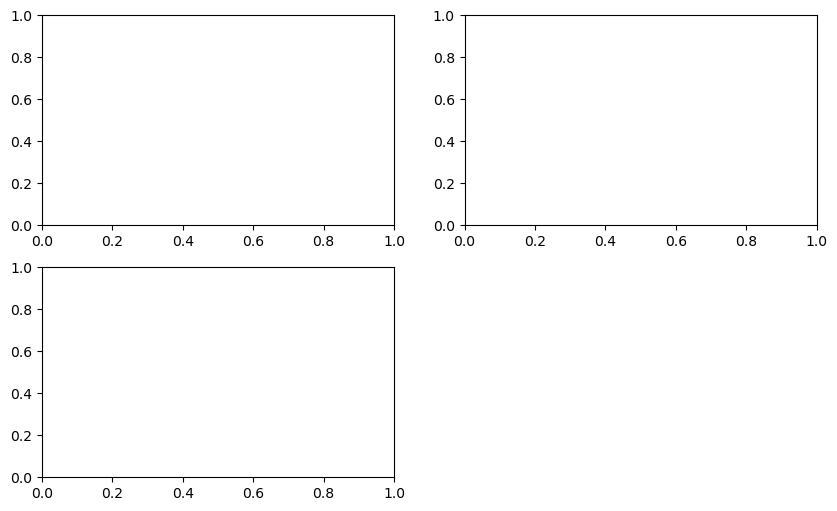

In [10]:
# Plots in matplotlib reside within a Figure object. You can create a new figure with plt.figure:
# An empty matplotlib figure with three subplots
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
plt.show()

In IPython, if you first run %matplotlib to set up the matplotlib integration, an empty plot window will appear, but in Jupyter nothing will be shown until we use a few more commands.

plt.figure has a number of options; notably, figsize will guarantee the figure has a certain size and aspect ratio if saved to disk.

You can’t make a plot with a blank figure. You have to create one or more subplots using add_subplot:

This means that the figure should be 2 × 2 (so up to four plots in total), and we’re
selecting the first of four subplots (numbered from 1). If you create the next two
subplots, you’ll end up with a visualization that looks like the figure above.

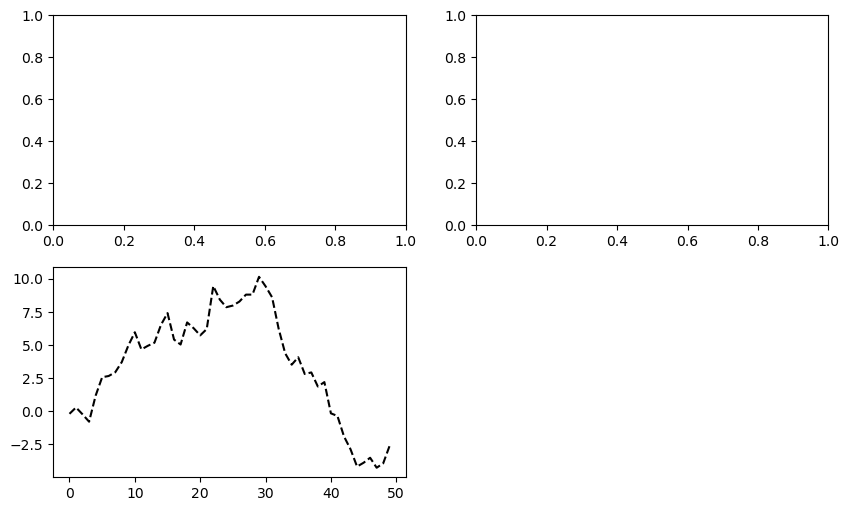

In [12]:
# These plot axis objects have various methods that create different types of plots,
# and it is preferred to use the axis methods over the top-level plotting functions
# like plt.plot. For example, we could make a line plot with the plot method.
# You may notice output like <matplotlib.lines.Line2D at ...> when you run this.
# matplotlib returns objects that reference the plot subcomponent that was just added.
# A lot of the time you can safely ignore this output, or you can put a semicolon at the
# end of the line to suppress the output.
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(np.random.standard_normal(50).cumsum(), color="black",
         linestyle="dashed")
plt.show()

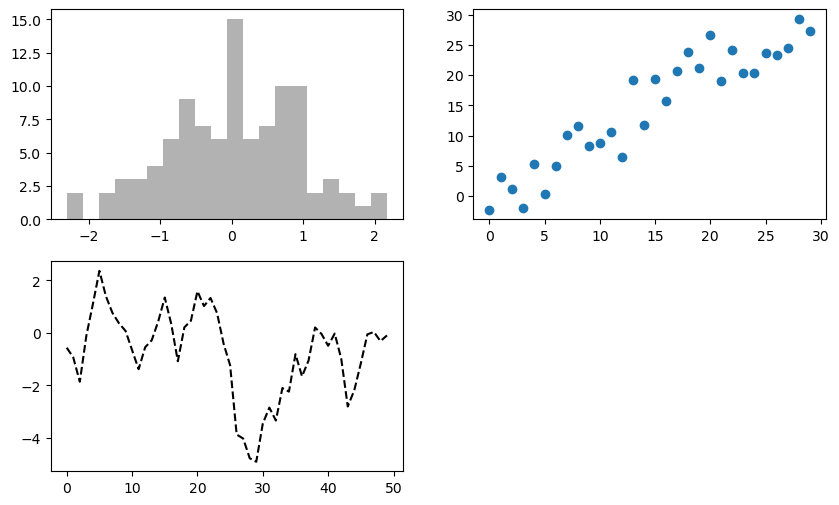

In [14]:
# The additional options instruct matplotlib to plot a black dashed line. The objects
# returned by fig.add_subplot here are AxesSubplot objects, on which you can
# directly plot on the other empty subplots by calling each one’s instance method.
# The style option alpha=0.3 sets the transparency of the overlaid plot.
# You can find a comprehensive catalog of plot types in the matplotlib documentation.
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color="black",
         linestyle="dashed")
plt.show()

In [16]:
plt.close("all")

The axes array can then be indexed like a two-dimensional array; for example,
axes[0, 1] refers to the subplot in the top row at the center. You can also indicate that subplots should have the same x- or y-axis using sharex and sharey, respectively. This can be useful when you’re comparing data on the same scale; otherwise, matplotlib autoscales plot limits independently.

In [19]:
fig, axes = plt.subplots(2, 3)
axes

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

By default, matplotlib leaves a certain amount of padding around the outside of the
subplots and in spacing between subplots. This spacing is all specified relative to the
height and width of the plot, so that if you resize the plot either programmatically
or manually using the GUI window, the plot will dynamically adjust itself. You can
change the spacing using the subplots_adjust method on Figure objects.

wspace and hspace control the percent of the figure width and figure height, respectively, to use as spacing between subplots. Here is a small example you can execute in
Jupyter where I shrink the spacing all the way to zero

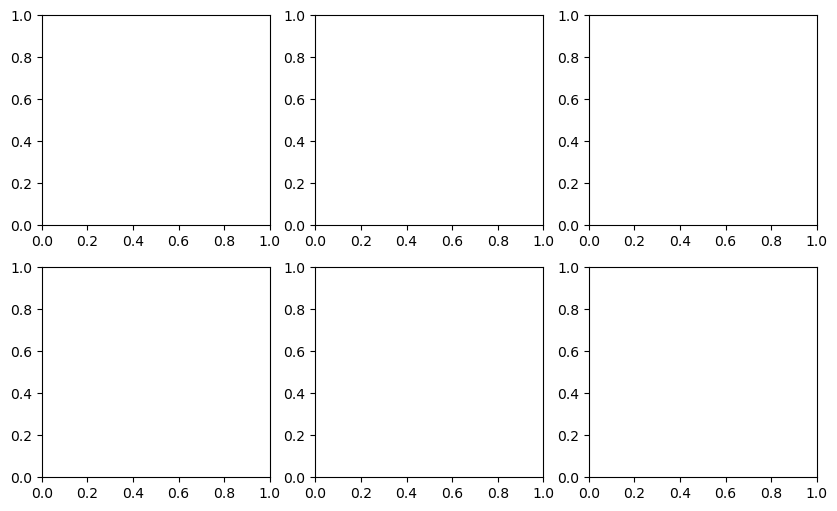

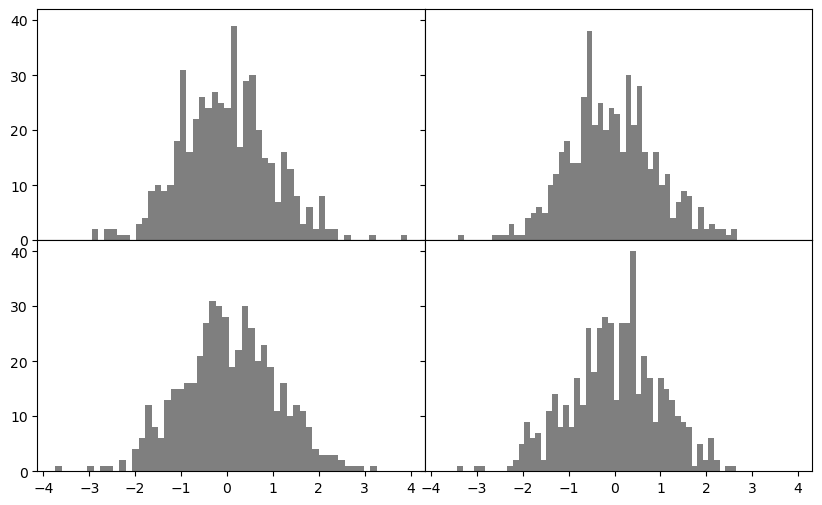

In [22]:
# check out matplotlib.pyplot.subplots options (nrows, ncols, sharex, sharey)
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50,
                        color="black", alpha=0.5)
fig.subplots_adjust(wspace=0, hspace=0)
plt.show()

Colors, Markers, and Line Styles

matplotlib’s line plot function accepts arrays of x and y coordinates and optional color styling options. For example, to plot x versus y with green dashes, you would execute below.

Line plots can additionally have markers to highlight the actual data points. Since
matplotlib’s plot function creates a continuous line plot, interpolating between
points, it can occasionally be unclear where the points lie. The marker can be
supplied as an additional styling option.

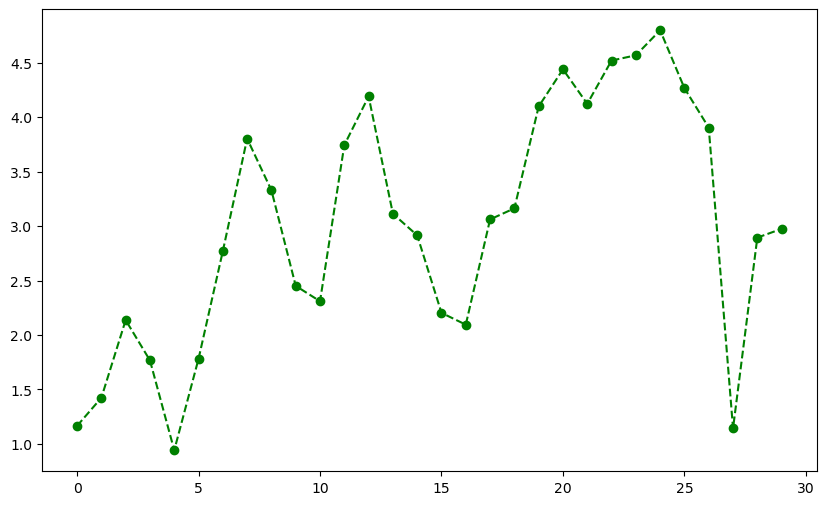

In [25]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color="green",
        linestyle="dashed", marker="o");
plt.show()

In [27]:
plt.close("all")

For line plots, you will notice that subsequent points are linearly interpolated by
default. This can be altered with the drawstyle option

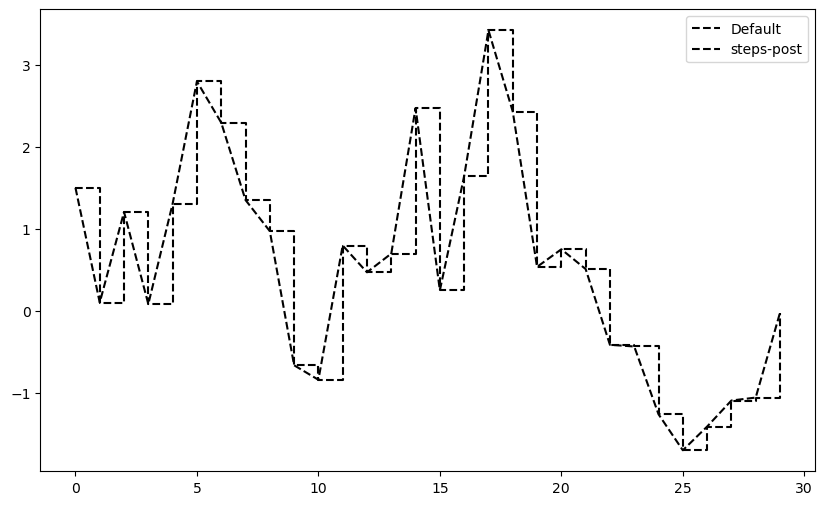

In [30]:
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()
ax.plot(data, color="black", linestyle="dashed", label="Default");
ax.plot(data, color="black", linestyle="dashed",
        drawstyle="steps-post", label="steps-post");
ax.legend()
# The legend() function displays a box with descriptions of each plot,
# using the labels provided in the label parameter of the plotting functions.
# Here, since we passed the label arguments to plot, we are able to create a plot legend
# to identify each line using ax.legend
plt.show()

Ticks, Labels, and Legends:

Most kinds of plot decorations can be accessed through methods on matplotlib axes
objects. This includes methods like xlim, xticks, and xticklabels. These control the
plot range, tick locations, and tick labels, respectively. They can be used in two ways:

• Called with no arguments returns the current parameter value (e.g., ax.xlim()
returns the current x-axis plotting range)

• Called with parameters sets the parameter value (e.g., ax.xlim([0, 10]) sets the
x-axis range to 0 to 10)

All such methods act on the active or most recently created AxesSubplot. Each
corresponds to two methods on the subplot object itself; in the case of xlim, these are
ax.get_xlim and ax.set_xlim.

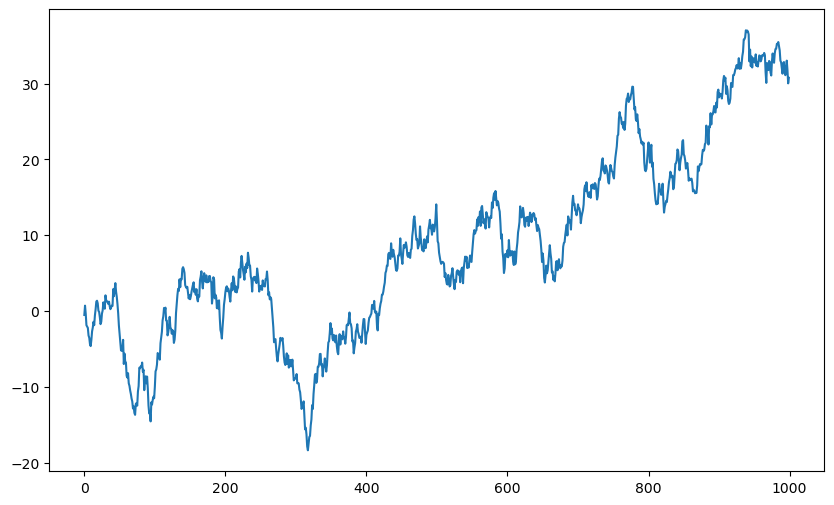

In [33]:
# Setting the title, axis labels, ticks, and tick labels
# To illustrate customizing the axes, I’ll create a simple figure and plot of a random
# walk
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
plt.show()

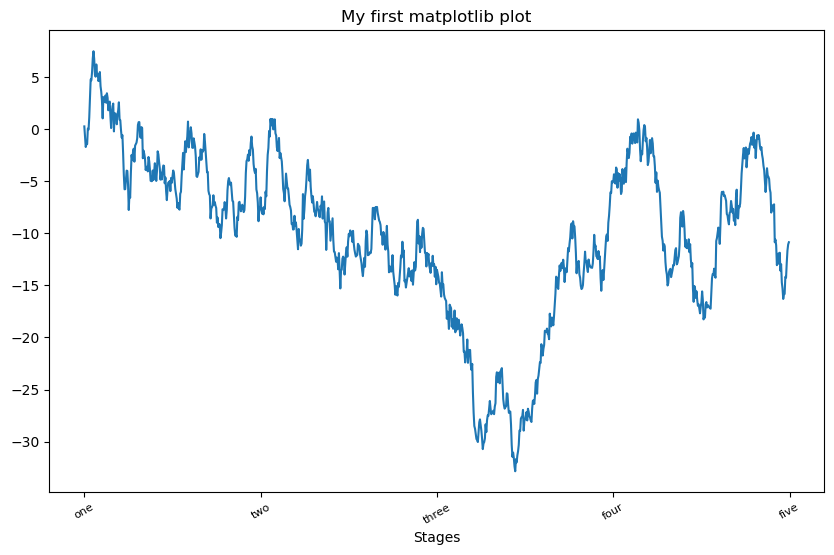

In [35]:
# To change the x-axis ticks, it’s easiest to use set_xticks and set_xticklabels. The
# former instructs matplotlib where to place the ticks along the data range; by default
# these locations will also be the labels. But we can set any other values as the labels
# using set_xticklabels:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum());
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(["one", "two", "three", "four", "five"],
                            rotation=30, fontsize=8)
ax.set_xlabel("Stages")
ax.set_title("My first matplotlib plot")
# The rotation option sets the x tick labels at a 30-degree rotation. Lastly, set_xlabel
# gives a name to the x-axis, and set_title is the subplot title.
# Modifying the y-axis consists of the same process, substituting y for x in this example.
# The axes class has a set method that allows batch setting of plot properties.
plt.show()

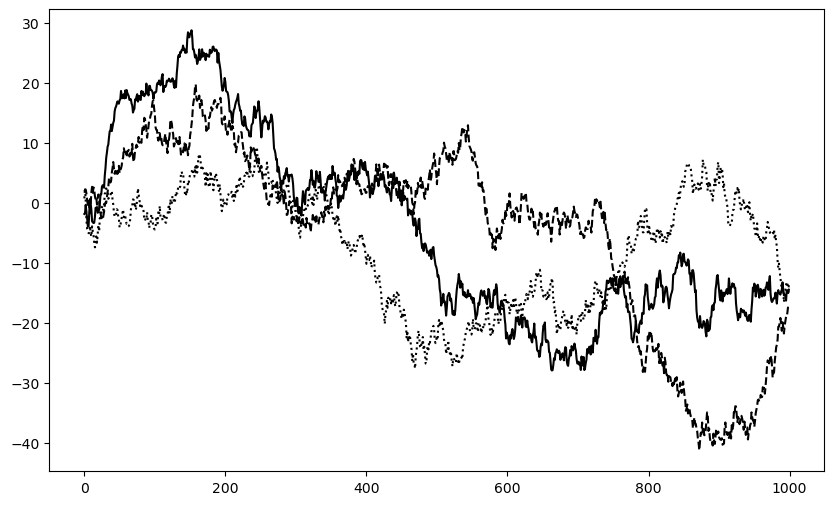

In [37]:
# Legends are another critical element for identifying plot elements. There are a couple
# of ways to add one. The easiest is to pass the label argument when adding each piece
# of the plot:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="black", label="one");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed",
        label="two");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted",
        label="three");
plt.show()

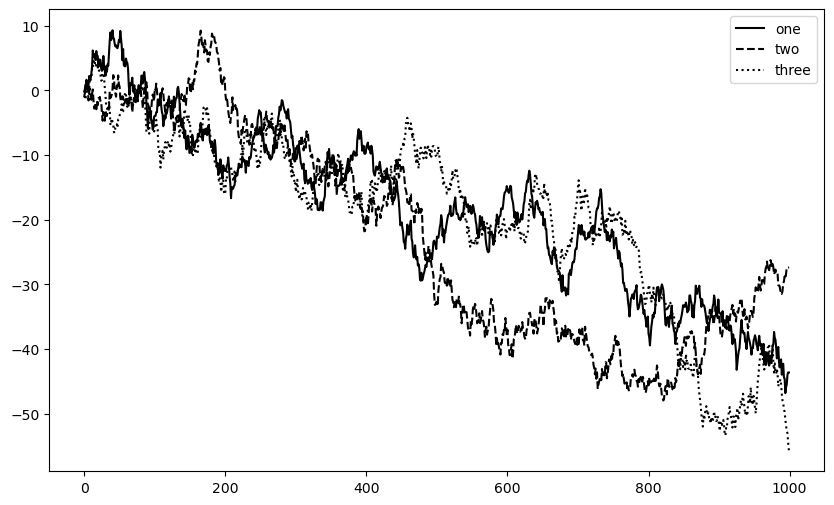

In [39]:
# Legends are another critical element for identifying plot elements. There are a couple
# of ways to add one. The easiest is to pass the label argument when adding each piece
# of the plot:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="black", label="one");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed",
        label="two");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted",
        label="three");
ax.legend()
plt.show()

The legend method has several other choices for the location loc argument. See the
docstring (with ax.legend?) for more information.

The loc legend option tells matplotlib where to place the plot. The default is "best",
which tries to choose a location that is most out of the way. To exclude one or more
elements from the legend, pass no label or label="_nolegend_".

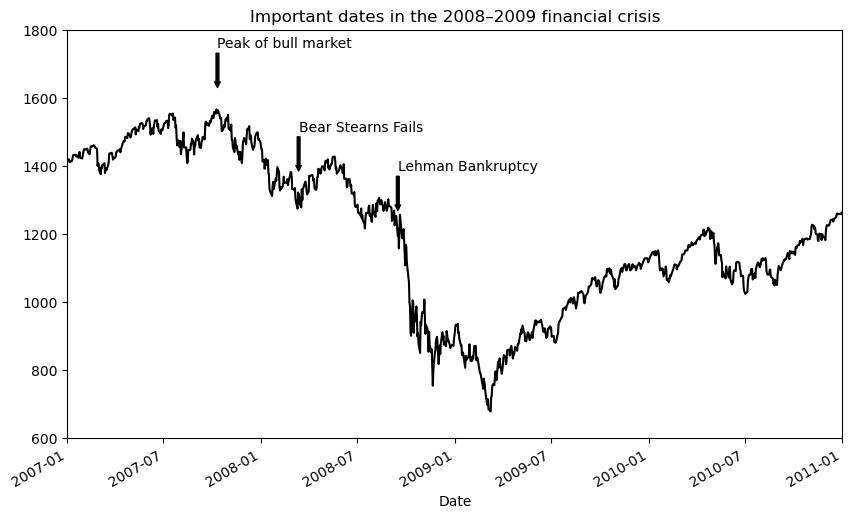

In [42]:
from datetime import datetime

fig, ax = plt.subplots()

data = pd.read_csv("spx.csv", index_col=0, parse_dates=True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
                horizontalalignment="left", verticalalignment="top")

# Zoom in on 2007-2010
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([600, 1800])

ax.set_title("Important dates in the 2008–2009 financial crisis")
plt.show()

In [46]:
ax.set_title("Important dates in the 2008–2009 financial crisis")

Text(0.5, 1.0, 'Important dates in the 2008–2009 financial crisis')

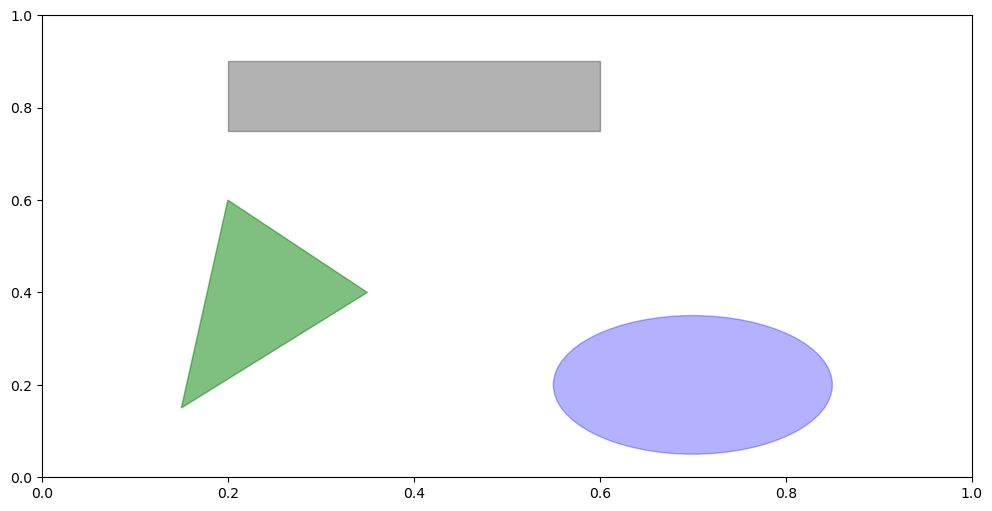

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color="green", alpha=0.5)
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
plt.show()

In [50]:
plt.close("all")

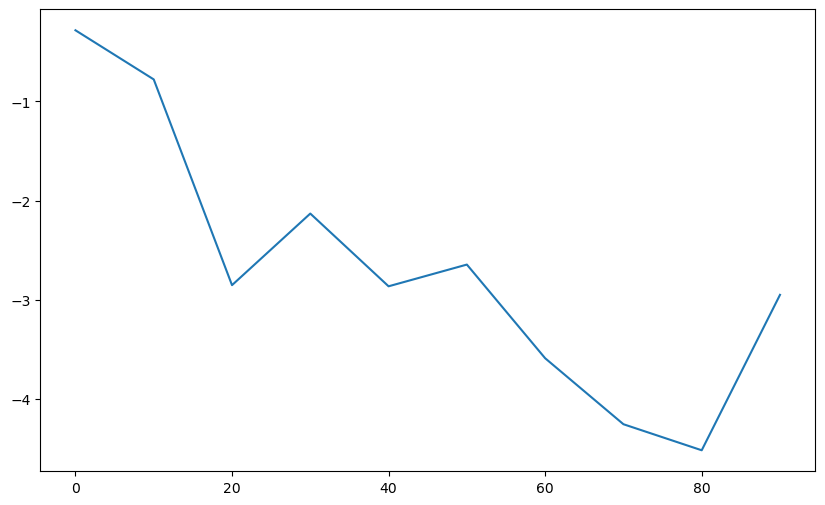

In [52]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()
plt.show()

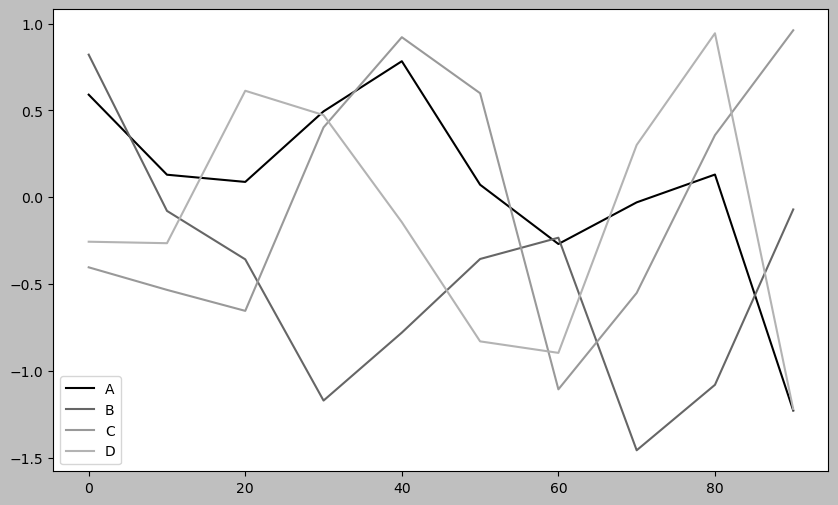

In [54]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=["A", "B", "C", "D"],
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot()
plt.show()

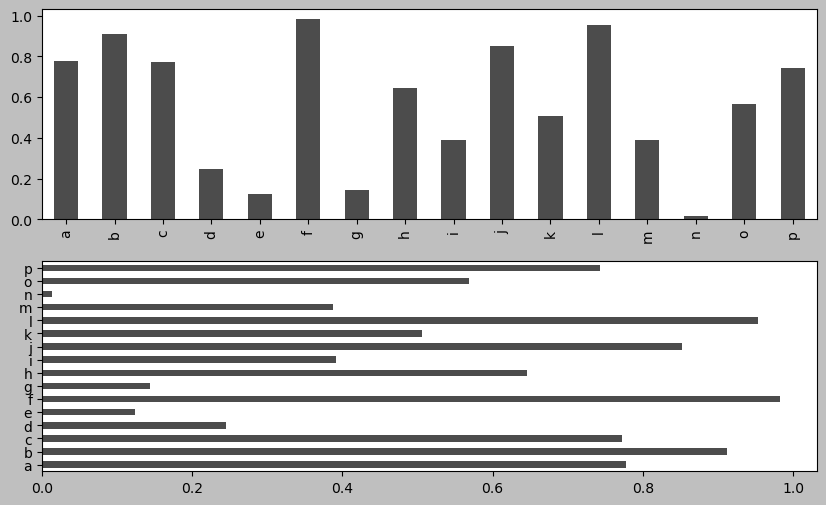

In [56]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)
plt.show()

In [58]:
np.random.seed(12348)

In [60]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
df
df.plot.bar()

<Axes: >

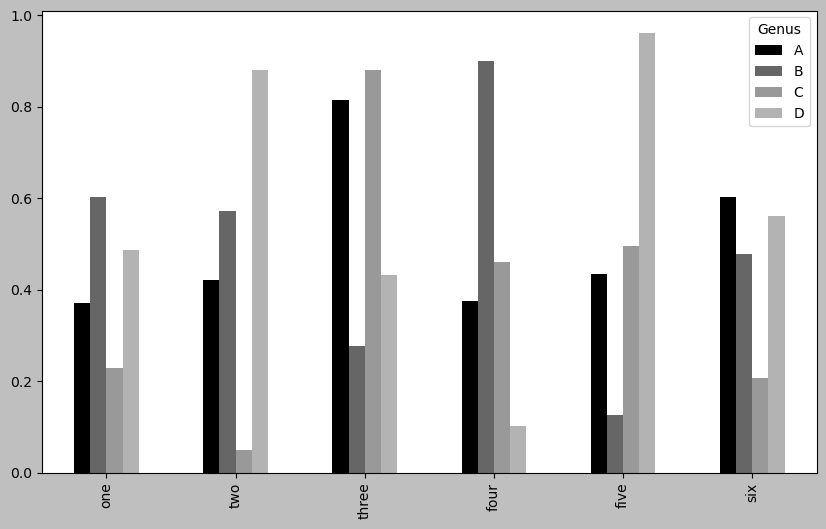

<Figure size 1000x600 with 0 Axes>

In [62]:
plt.figure()
plt.show()

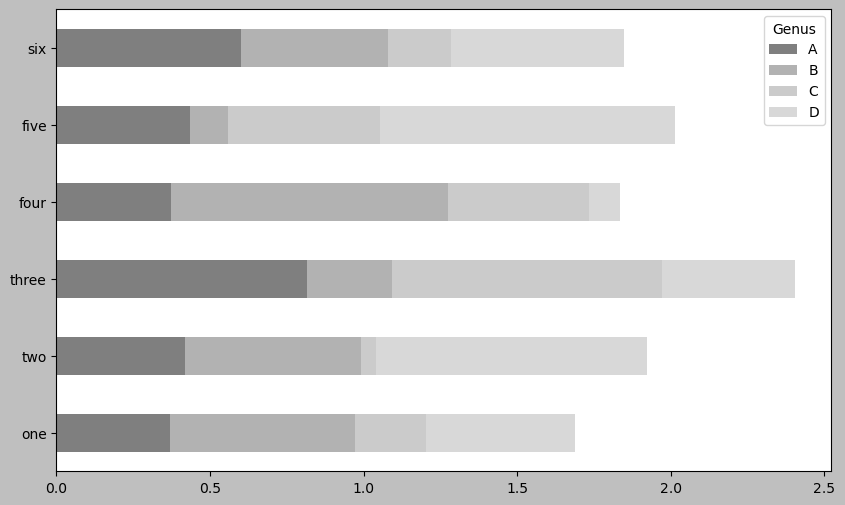

In [64]:
df.plot.barh(stacked=True, alpha=0.5)
plt.show()

In [66]:
plt.close("all")

In [68]:
tips = pd.read_csv("tips.csv")
tips.head()
party_counts = pd.crosstab(tips["day"], tips["size"])
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


In [70]:
party_counts = party_counts.loc[:, 2:5]

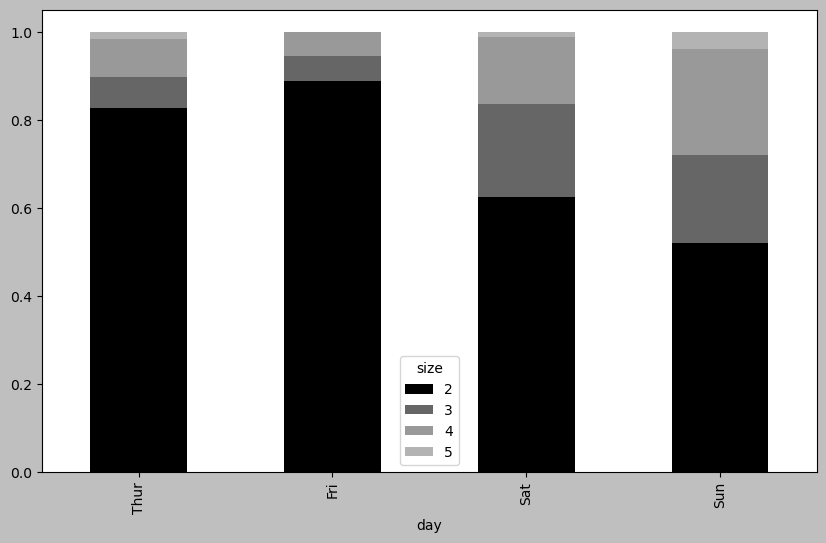

In [72]:
# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(axis="columns"),
                              axis="index")
party_pcts
party_pcts.plot.bar(stacked=True)
plt.show()

In [74]:
plt.close("all")

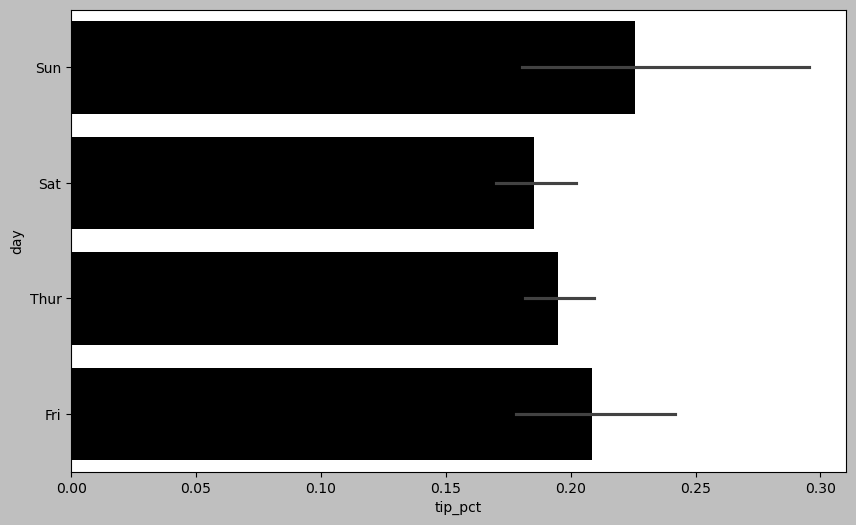

In [76]:
import seaborn as sns

tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])
tips.head()
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")
plt.show()

In [78]:
plt.close("all")

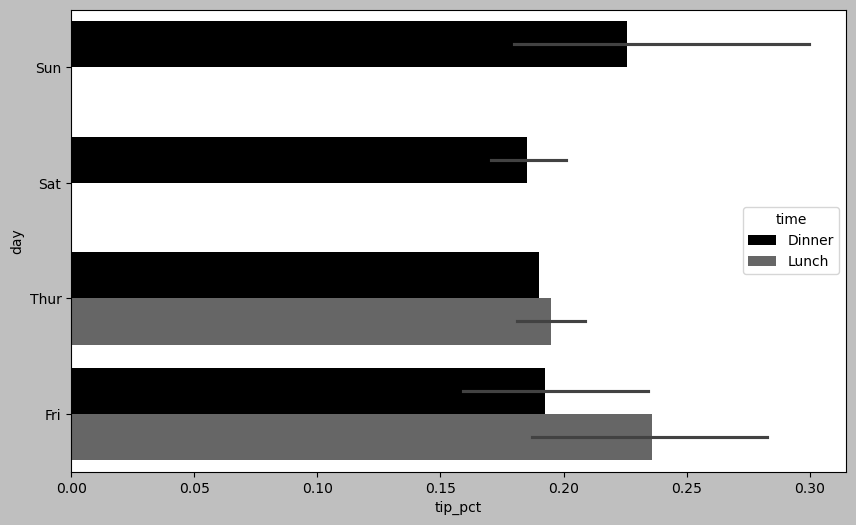

In [80]:
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")
plt.show()

In [82]:
plt.close("all")

In [86]:
sns.set_style("whitegrid")

In [88]:
plt.figure()
plt.show()

<Figure size 1000x600 with 0 Axes>

In [90]:
tips["tip_pct"].plot.hist(bins=50)

<Axes: ylabel='Frequency'>

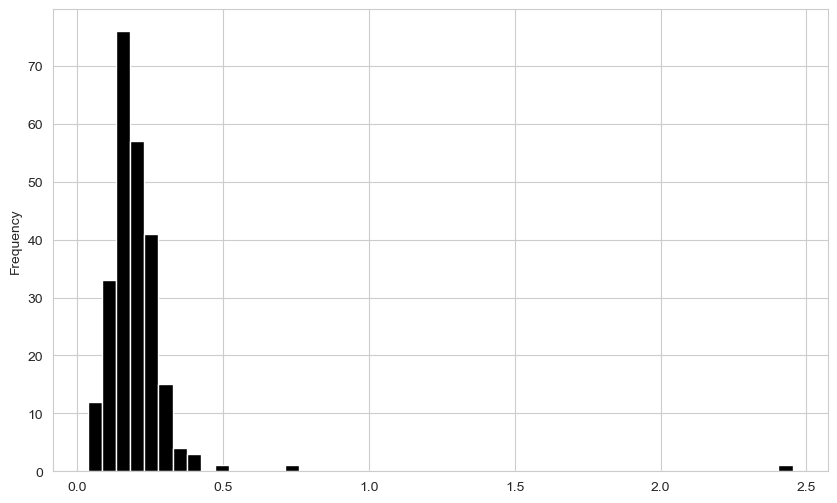

<Figure size 1000x600 with 0 Axes>

In [92]:
plt.figure()
plt.show()

In [94]:
tips["tip_pct"].plot.density()

<Axes: ylabel='Density'>

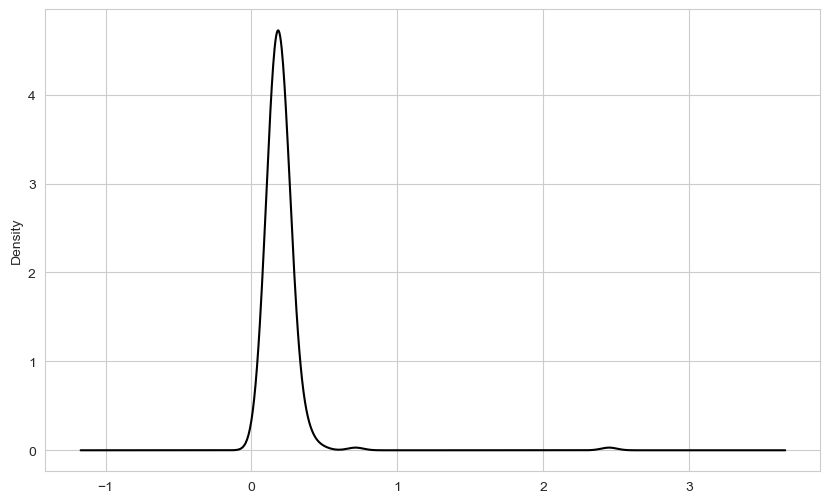

<Figure size 1000x600 with 0 Axes>

In [96]:
plt.figure()
plt.show()

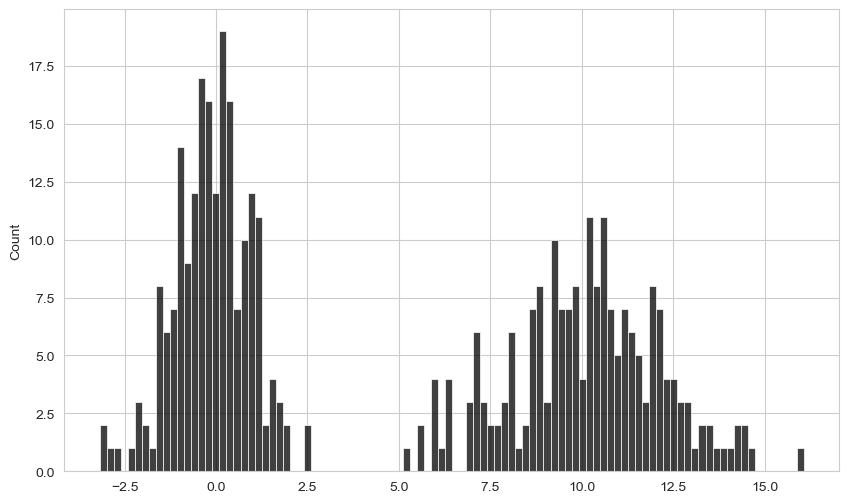

In [98]:
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([comp1, comp2]))

sns.histplot(values, bins=100, color="black")
plt.show()

In [100]:
macro = pd.read_csv("macrodata.csv")
data = macro[["cpi", "m1", "tbilrate", "unemp"]]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


In [102]:
plt.figure()
plt.show()

<Figure size 1000x600 with 0 Axes>

In [104]:
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)")

Text(0.5, 1.0, 'Changes in log(m1) versus log(unemp)')

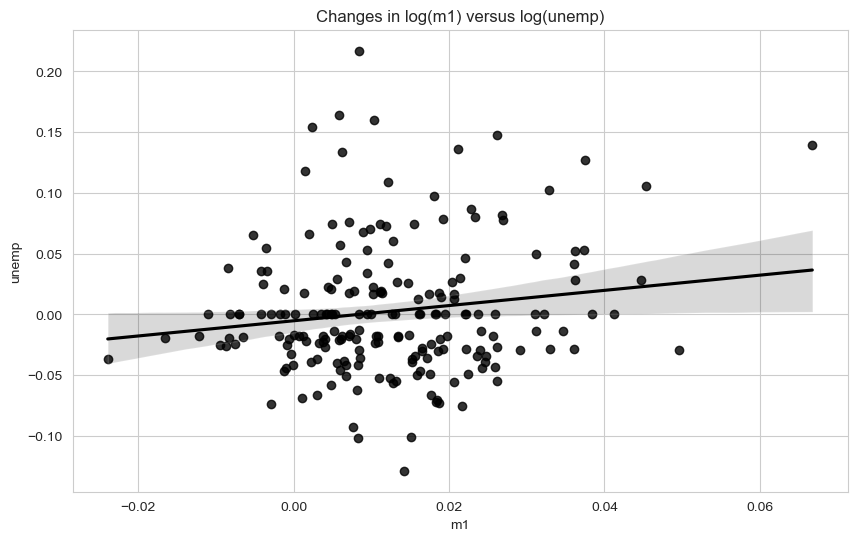

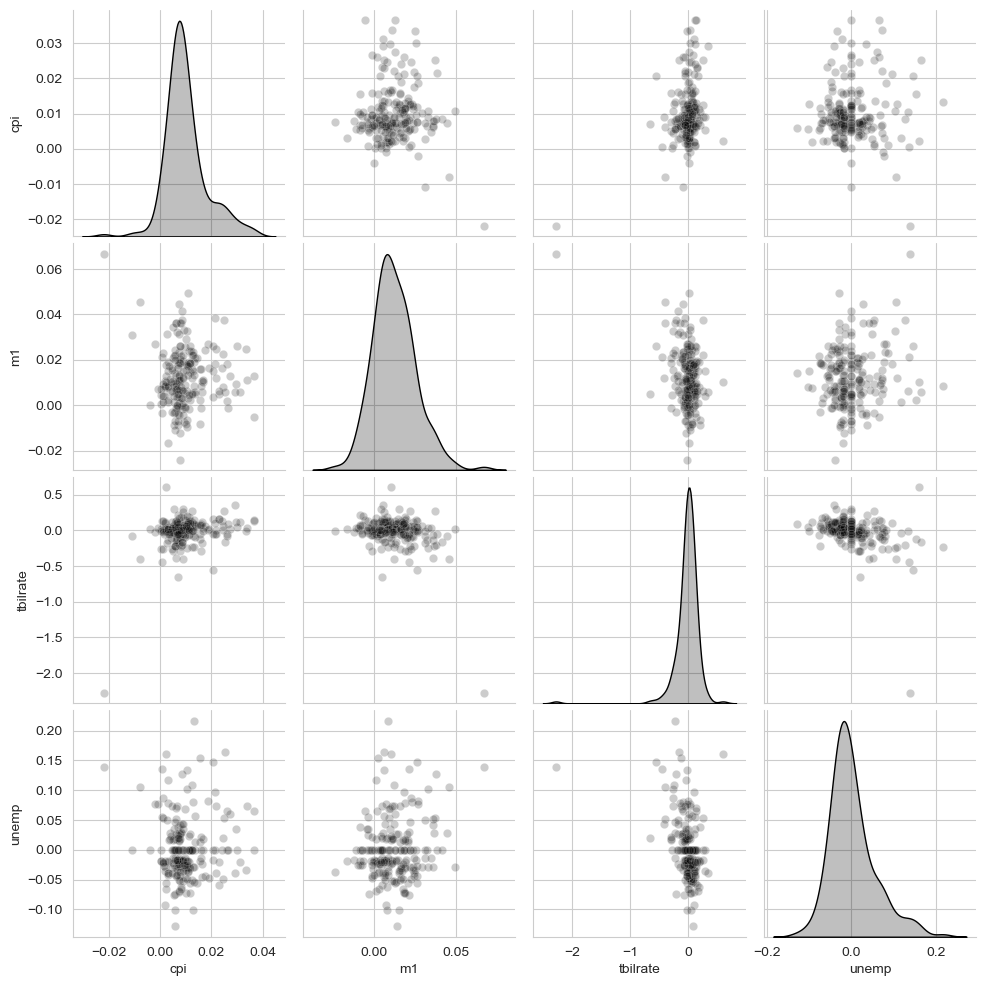

In [106]:
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})
plt.show()

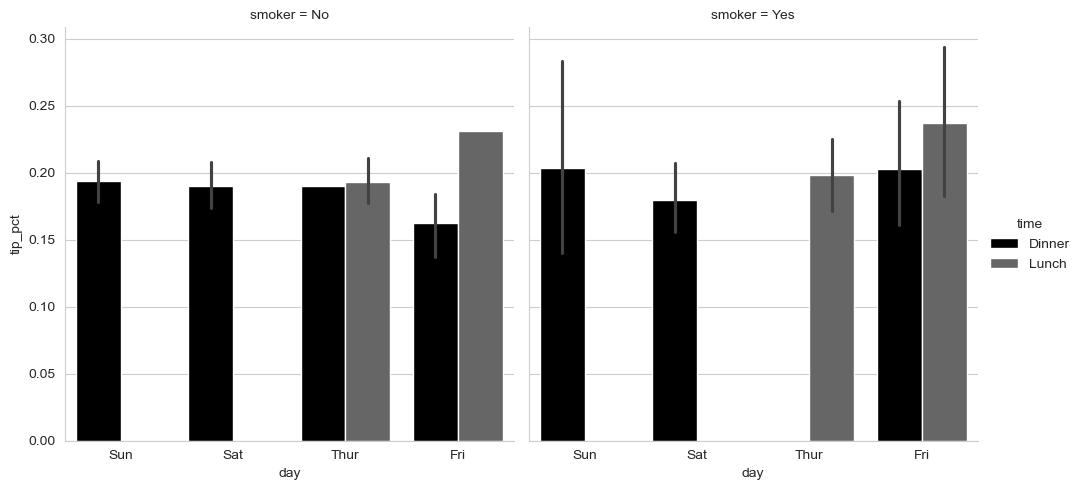

In [108]:
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1])
plt.show()

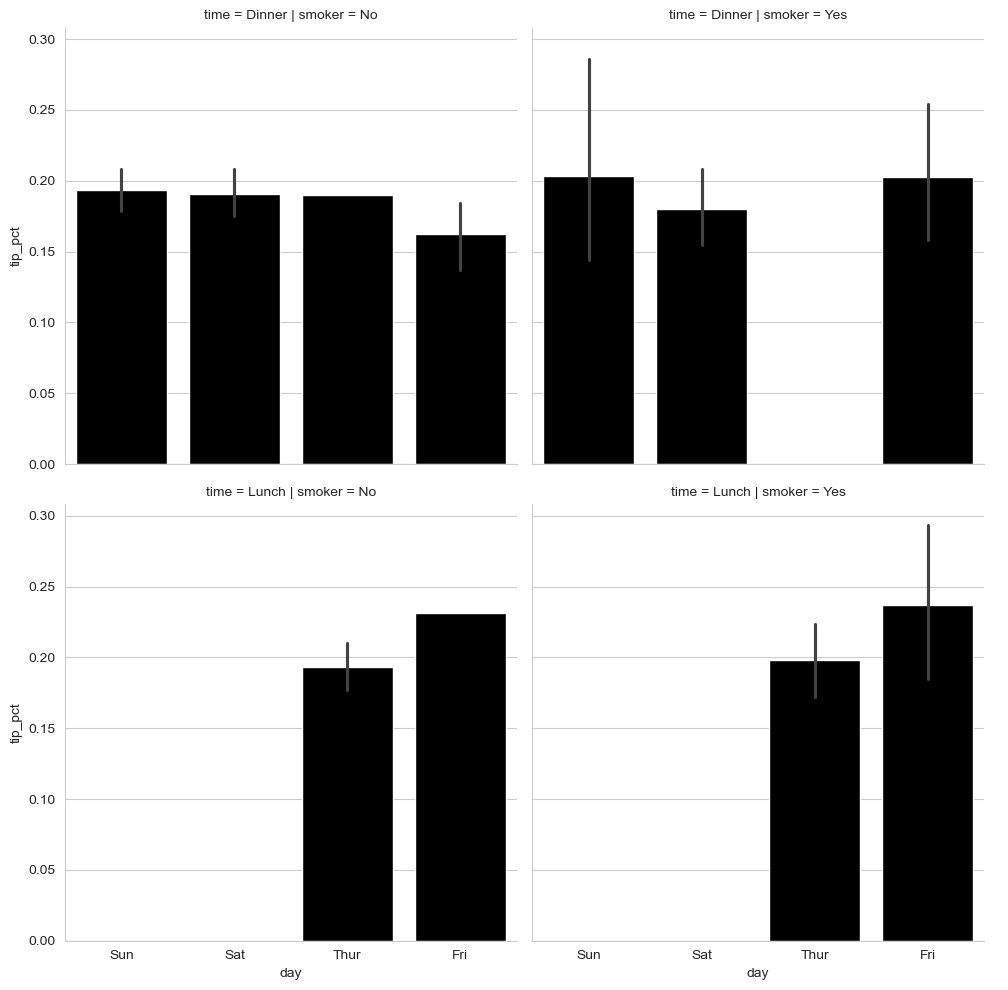

In [110]:
sns.catplot(x="day", y="tip_pct", row="time",
            col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1])
plt.show()

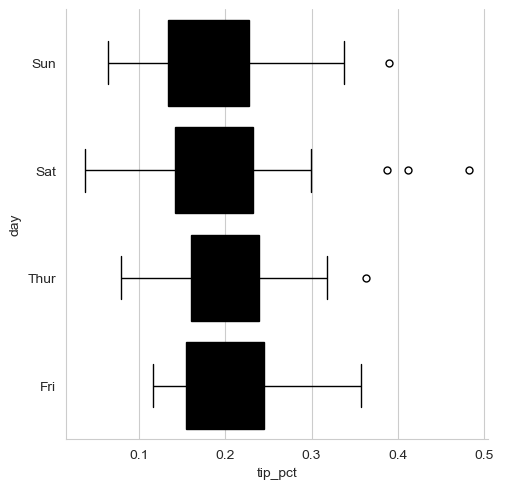

In [112]:
sns.catplot(x="tip_pct", y="day", kind="box",
            data=tips[tips.tip_pct < 0.5])
plt.show()

In [114]:
pd.options.display.max_rows = PREVIOUS_MAX_ROWS